<a href="https://colab.research.google.com/github/AwaisSDev/Quantization-Collapse-Predictor/blob/main/Quant%20Collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_fea

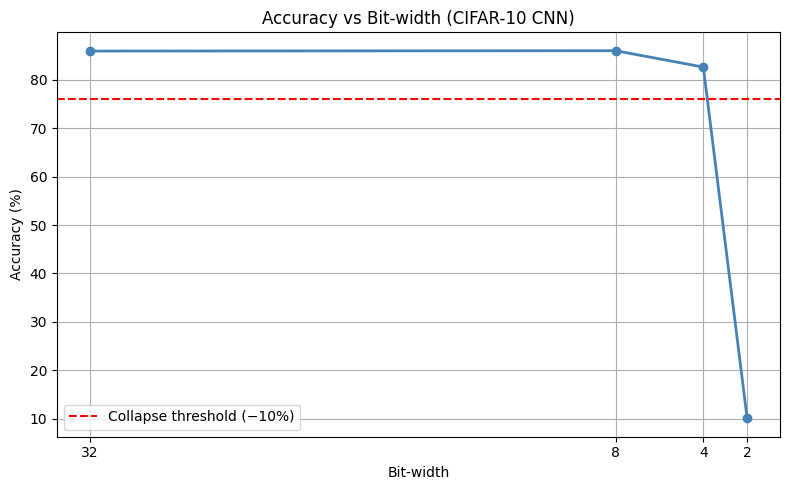

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train(model, epochs=25):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/25 | Loss: {total_loss/len(trainloader):.4f}")

train(model)
torch.save(model.state_dict(), "cnn_fp32.pth")
print("Model saved.")

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

fp32_acc = evaluate(model)
print(f"FP32 Accuracy: {fp32_acc:.2f}%")

def quantize_model(model, bits):
    q_model = copy.deepcopy(model).cpu()
    q_model.eval()
    for name, module in q_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data
            w_min, w_max = w.min(), w.max()
            levels = 2 ** bits
            scale = (w_max - w_min) / (levels - 1)
            w_q = torch.round((w - w_min) / scale) * scale + w_min
            module.weight.data = w_q
    return q_model.to(device)

results = {}
for bits in [8, 4, 2]:
    q_model = quantize_model(model, bits)
    acc = evaluate(q_model)
    drop = fp32_acc - acc
    results[bits] = {"accuracy": acc, "drop": drop}
    print(f"{bits}-bit | Accuracy: {acc:.2f}% | Drop: {drop:.2f}%")

    bit_widths = [32, 8, 4, 2]
accuracies = [fp32_acc] + [results[b]["accuracy"] for b in [8, 4, 2]]

plt.figure(figsize=(8, 5))
plt.plot(bit_widths, accuracies, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=fp32_acc - 10, color='red', linestyle='--', label='Collapse threshold (−10%)')
plt.xlabel("Bit-width")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Bit-width (CIFAR-10 CNN)")
plt.xticks([2, 4, 8, 32])
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("accuracy_vs_bitwidth.png", dpi=150)
plt.show()